### Model Evaluation 

In [1]:
## Libraries to be used 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
model_performance_data = pd.read_parquet('../datas/modelpeformance.parquet')
model_performance_data.head(5)

,model,mae,rmse,r2,AAPL,AMD,AVGO,GOOGL,HD,JNJ,...,MSFT,MU,NFLX,NVDA,ORCL,PG,QCOM,TSLA,UNH,WMT
0,xgboost,0.004276,0.007295,0.751110,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,lstm,0.004710,0.007832,0.707376,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,rnn,0.004637,0.007723,0.715447,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,garch,0.006596,0.009761,0.554551,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,NaN,NaN,NaN,NaN,"{'alpha': 0.11836742655033004, 'beta': 0.84210...","{'alpha': 0.16080309785188313, 'beta': 0.74627...","{'alpha': 0.1163909842282521, 'beta': 0.762623...","{'alpha': 0.07818717283725404, 'beta': 0.88636...","{'alpha': 0.12458979976224359, 'beta': 0.84209...","{'alpha': 0.10332708192885381, 'beta': 0.86093...",...,"{'alpha': 0.1456748218444877, 'beta': 0.801292...","{'alpha': 0.047097568666711435, 'beta': 0.9300...","{'alpha': 0.012605933384080953, 'beta': 0.9842...","{'alpha': 0.12115940186347626, 'beta': 0.84970...","{'alpha': 0.1355160223887985, 'beta': 0.799014...","{'alpha': 0.14007070719035336, 'beta': 0.80466...","{'alpha': 0.15040816405424848, 'beta': 0.78023...","{'alpha': 0.029781793115113194, 'beta': 0.9608...","{'alpha': 0.05653505092684767, 'beta': 0.93603...","{'alpha': 0.13962900354075786, 'beta': 0.79252..."


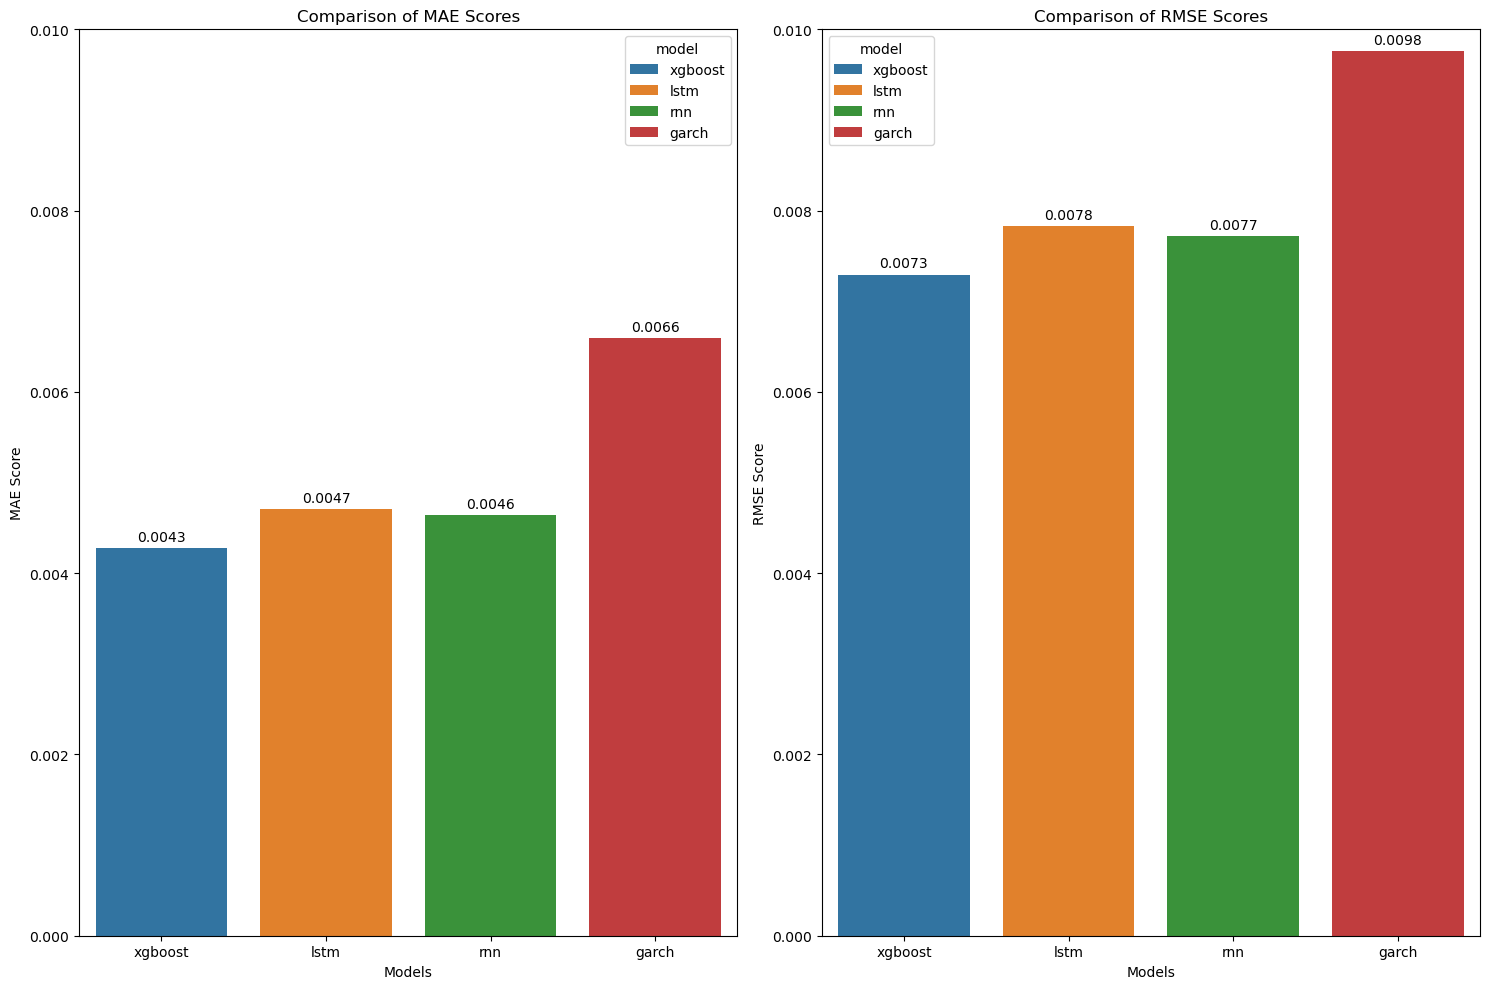

In [3]:
### Comparison of model's performance
fix, ax = plt.subplots(1,2,figsize = (15,10))
def plottingmetrics(x,y, data, title, xlabel, ylabel, ylim1, ylim2, axes):
    sns.barplot(x = x, y =y, data = data, hue = x, ax = axes)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.set_ylim(ylim1, ylim2)
    for container in axes.containers:
        axes.bar_label(container, fmt="%.4f", padding=3)

plottingmetrics('model', 'mae', model_performance_data, 'Comparison of MAE Scores', 'Models', 'MAE Score', 0, 0.01, ax[0])
plottingmetrics('model', 'rmse', model_performance_data, 'Comparison of RMSE Scores', 'Models', 'RMSE Score', 0, 0.01, ax[1])
plt.tight_layout()
plt.savefig("../modelperformance/maeandrmsescores.png")
plt.show()

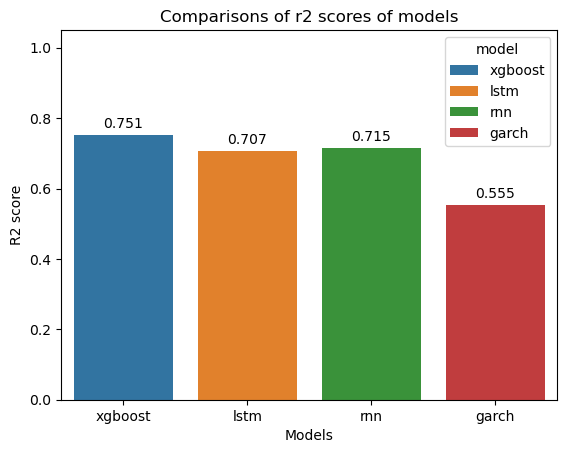

In [4]:
## R2 Score comparison between the models 
ax = sns.barplot(x='model', y='r2', data=model_performance_data, hue='model')

plt.xlabel("Models")
plt.ylabel("R2 score")
plt.ylim(0, 1.05)  # optional, gives labels some space
plt.title("Comparisons of r2 scores of models")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.savefig("../modelperformance/r2scores.png")
plt.show()